In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [81]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")
df = pd.read_csv(path+f'/Student_Performance.csv')

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.


In [82]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [83]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [84]:
df = df[['Previous Scores', 'Performance Index']]

In [85]:
df.head()

,Previous Scores,Performance Index
0,99,91.0
1,82,65.0
2,51,45.0
3,52,36.0
4,75,66.0


In [86]:
df.columns = ['Scores', 'Performance']

In [87]:
df.head()

,Scores,Performance
0,99,91.0
1,82,65.0
2,51,45.0
3,52,36.0
4,75,66.0


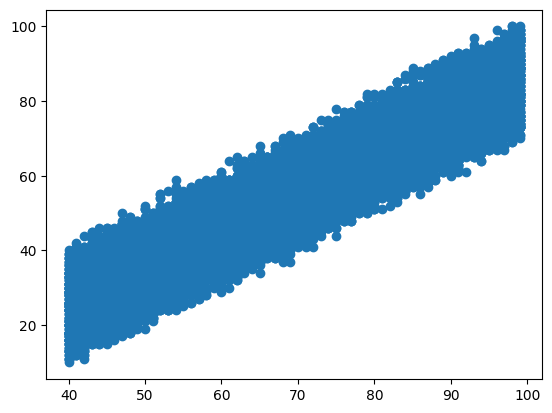

In [88]:
plt.scatter(df['Scores'], df['Performance'])

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train, X_test,y_train, y_test = train_test_split(df['Scores'], df['Performance'], test_size= 0.2, random_state= 42)

In [91]:
from sklearn.linear_model import LinearRegression

In [92]:
lr = LinearRegression()

In [93]:
lr.fit(X_train.values.reshape(-1, 1), y_train)

LinearRegression()

In [94]:
lr.coef_

array([1.0127272])

In [95]:
lr.intercept_

np.float64(-15.10443514609134)

In [96]:
def intercept_gd(X_train, y_train, learning_rate, epochs):

  m = 1.0127272
  b = 0

  for i in range(epochs):
    y_pred = m * X_train.values.ravel() + b
    plt.plot(X_train.values, y_pred)
    loss_slope = -2 * np.sum(y_train.values - y_pred)
    step_size = learning_rate * loss_slope
    b = b - step_size
  return b


np.float64(-15.104434538593285)

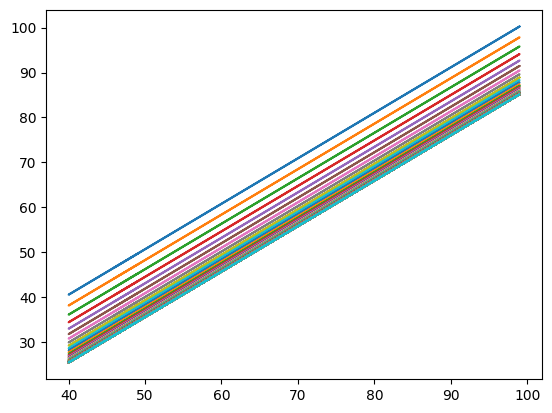

In [97]:
plt.plot(X_train.values, lr.predict(X_train.values.reshape(-1, 1)), color = 'red')
intercept_gd(X_train, y_train, 0.00001, 100)

In [106]:
def gradient_descent_slope(X_train, y_train,learning_rate, epochs):

  m = -10
  b = -15.10443514609134
  n = X_train.values.shape[0]
  for i in range(epochs):
    y_pred = m * X_train.values.ravel() + b
    plt.plot(X_train.values, y_pred)
    loss_slope = -(2 * np.mean(X_train.values * (y_train.values - y_pred)))
    step_size = learning_rate * loss_slope
    m = m - step_size
  return  m

In [107]:
X_train.values.shape[0]

8000

np.float64(1.0127272029179983)

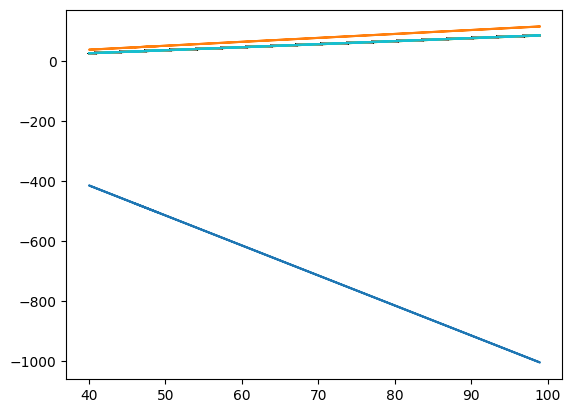

In [108]:
gradient_descent_slope(X_train, y_train, 0.0001, 1000)